No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


警告: 文件 ../data/local/garage/eplus_ppo_year_22/progress.csv 中缺少列 Epoch 或 Evaluation/AverageReturn
警告: 文件 ../data/local/garage/eplus_ppo_year_20/progress.csv 中缺少列 Epoch 或 Evaluation/AverageReturn
对比图已保存为 return_comparison.png


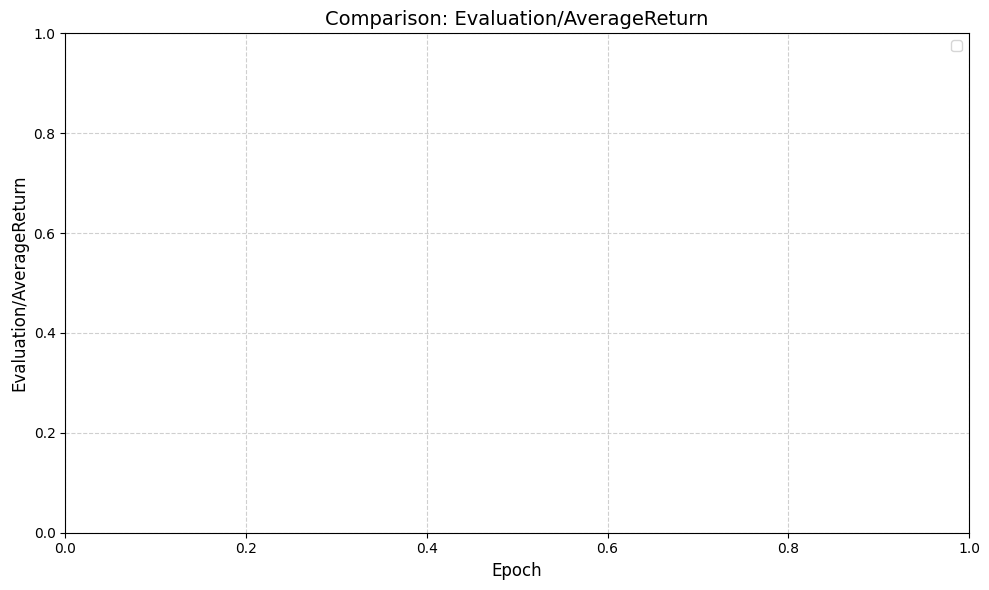

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_comparison(file_configs, x_axis='Epoch', y_axis='Evaluation/AverageReturn', window_size=5):
    """
    绘制多个 garage progress.csv 的对比曲线
    
    Args:
        file_configs: 包含文件路径和标签的列表 [ {'path': '...', 'label': '...'}, ... ]
        x_axis: 横坐标列名，通常是 'Epoch' 或 'TotalEnvSteps'
        y_axis: 纵坐标列名，这里是 'Evaluation/AverageReturn'
        window_size: 平滑窗口大小，1表示不平滑
    """
    plt.figure(figsize=(10, 6))
    
    for config in file_configs:
        path = config['path']
        label = config['label']
        
        if not os.path.exists(path):
            print(f"警告: 文件未找到 {path}")
            continue
            
        # 读取数据
        df = pd.read_csv(path)
        
        if x_axis not in df.columns or y_axis not in df.columns:
            print(f"警告: 文件 {path} 中缺少列 {x_axis} 或 {y_axis}")
            continue

        # 提取数据
        x = df[x_axis]
        y = df[y_axis]
        
        # 绘制原始曲线（浅色透明）
        plt.plot(x, y, alpha=0.3, color=config.get('color'))
        
        # 绘制平滑曲线（深色）
        y_smoothed = y.rolling(window=window_size, min_periods=1).mean()
        plt.plot(x, y_smoothed, label=f"{label} (Smooth)", linewidth=2, color=config.get('color'))

    plt.title(f'Comparison: {y_axis}', fontsize=14)
    plt.xlabel(x_axis, fontsize=12)
    plt.ylabel(y_axis, fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # 保存图片
    plt.savefig('return_comparison.png')
    print("对比图已保存为 return_comparison.png")
    plt.show()

if __name__ == "__main__":
    # 配置文件路径
    configs = [
        {
            'path': '../data/local/garage/eplus_ppo_year_22/progress.csv',
            'label': 'PPO Year 22',
            'color': 'blue'
        },
        {
            'path': '../data/local/garage/eplus_ppo_year_20/progress.csv',
            'label': 'PPO Year 20',
            'color': 'red'
        }
    ]

    # 执行绘图
    # 如果你想按步数对比，可以将 x_axis 改为 'TotalEnvSteps'
    plot_comparison(configs, x_axis='Epoch', y_axis='Evaluation/AverageReturn', window_size=10)

✅ 对比图已成功保存至: ppo_comparison_result.png


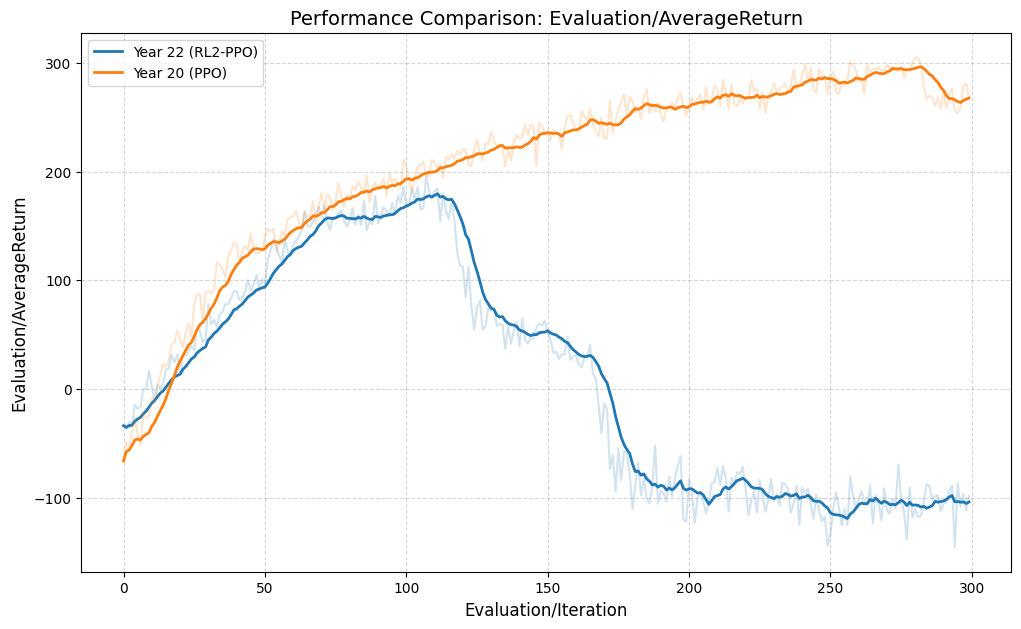

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_comparison(file_configs, x_axis='Evaluation/Iteration', y_axis='Evaluation/AverageReturn', window_size=5):
    """
    绘制 garage progress.csv 的对比曲线
    """
    plt.figure(figsize=(12, 7))
    found_any = False
    
    for config in file_configs:
        path = config['path']
        label = config['label']
        
        if not os.path.exists(path):
            print(f"❌ 错误: 找不到文件 -> {path}")
            continue
            
        # 读取数据
        df = pd.read_csv(path)
        
        # 检查列名是否存在 (去除可能存在的空格)
        df.columns = [c.strip() for c in df.columns]
        
        if x_axis not in df.columns or y_axis not in df.columns:
            print(f"⚠️ 警告: 文件 {path} 中缺少列!")
            print(f"   期望寻找: '{x_axis}' 和 '{y_axis}'")
            print(f"   文件中实际包含的列有: {list(df.columns[:5])} ... (共{len(df.columns)}列)")
            continue

        found_any = True
        x = df[x_axis]
        y = df[y_axis]
        
        # 绘制
        color = config.get('color')
        # 原始数据（半透明）
        plt.plot(x, y, alpha=0.2, color=color)
        # 平滑处理
        y_smoothed = y.rolling(window=window_size, min_periods=1).mean()
        plt.plot(x, y_smoothed, label=label, linewidth=2, color=color)

    if not found_any:
        print("❌ 没有任何匹配的数据可以绘制，请检查列名和路径。")
        return

    plt.title(f'Performance Comparison: {y_axis}', fontsize=14)
    plt.xlabel(x_axis, fontsize=12)
    plt.ylabel(y_axis, fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # 自动保存
    save_path = 'ppo_comparison_result.png'
    plt.savefig(save_path, dpi=300)
    print(f"✅ 对比图已成功保存至: {save_path}")
    plt.show()

if __name__ == "__main__":
    # 请确保这里的路径相对于你运行脚本的位置是正确的
    # 如果你在 eplus_ppo_year_22 同级目录下运行，可能不需要 ../
    configs = [
        {
            'path': '../data/local/garage/eplus_ppo_year_lstm/progress.csv', 
            'label': 'Year 22 (RL2-PPO)',
            'color': '#1f77b4' # 蓝色
        },
        {
            'path': '../data/local/garage/eplus_ppo_year_23/progress.csv',
            'label': 'Year 20 (PPO)',
            'color': '#ff7f0e' # 橙色
        }
    ]

    # 根据你的 CSV 内容：
    # 横轴建议用: 'Evaluation/Iteration' 或 'TotalEnvSteps'
    # 纵轴建议用: 'Evaluation/AverageReturn'
    plot_comparison(
        configs, 
        x_axis='Evaluation/Iteration', 
        y_axis='Evaluation/AverageReturn', 
        window_size=10
    )

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import os

def plot_all_metrics(file_path, x_axis='Evaluation/Iteration'):
    if not os.path.exists(file_path):
        print(f"文件不存在: {file_path}")
        return

    # 读取数据
    df = pd.read_csv(file_path)
    df.columns = [c.strip() for c in df.columns]

    # 排除掉作为横坐标的列，以及没有数值意义的列
    y_cols = [c for c in df.columns if c != x_axis and df[c].dtype != 'object']
    
    num_plots = len(y_cols)
    cols_per_row = 3
    rows = math.ceil(num_plots / cols_per_row)

    # 创建大图
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, 4 * rows))
    axes = axes.flatten()

    for i, col in enumerate(y_cols):
        ax = axes[i]
        # 绘制原始数据
        ax.plot(df[x_axis], df[col], alpha=0.3, color='gray')
        # 绘制平滑数据
        smoothed = df[col].rolling(window=5, min_periods=1).mean()
        ax.plot(df[x_axis], smoothed, label=col, linewidth=1.5)
        
        ax.set_title(col, fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.6)
        # 自动调整坐标轴，防止科学计数法遮挡
        ax.ticklabel_format(style='plain', axis='y', useOffset=False)
        plt.setp(ax.get_xticklabels(), rotation=30)

    # 隐藏多余的子图
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.suptitle(f"All Metrics for {os.path.basename(file_path)}", fontsize=16, y=1.02)
    
    save_name = "all_metrics_subplots.png"
    plt.savefig(save_name, bbox_inches='tight', dpi=150)
    print(f"所有指标已保存至: {save_name}")
    plt.show()

import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

import os
from pathlib import Path

def plot_csv_comparison(filepaths, column_names, tags=None, smooth_window=10):
    """
    对比多个CSV文件的特定列，并进行平滑处理。
    
    参数:
    - filepaths: list, 文件路径列表
    - column_names: list, 需要对比的列名列表
    - tags: list (可选), 每个文件对应的标签
    - smooth_window: int, 平滑窗口大小。1表示不平滑，数值越大越平滑。
    """
    
    # 1. 处理标签 (tags)
    if tags is None or len(tags) != len(filepaths):
        tags = [Path(p).parent.name for p in filepaths]

    # 2. 准备绘图
    num_plots = len(column_names)
    fig, axes = plt.subplots(num_plots, 1, figsize=(12, 6 * num_plots), squeeze=False)
    axes = axes.flatten()

    # 颜色循环，确保平滑线和原始线颜色一致
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    # 3. 遍历文件读取数据
    for i, (path, tag) in enumerate(zip(filepaths, tags)):
        if not os.path.exists(path):
            print(f"Warning: 文件不存在 -> {path}")
            continue
        
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"Warning: 读取文件 {path} 失败: {e}")
            continue

        color = colors[i % len(colors)] # 为每个文件分配一个固定颜色

        # 4. 在对应的子图中画出每一列
        for j, col in enumerate(column_names):
            ax = axes[j]
            if col in df.columns:
                data = df[col].dropna() # 排除空值
                
                if smooth_window > 1:
                    # 计算滑动平均
                    # min_periods=1 保证了数据开始部分不会因为窗口不足而出现空白
                    smoothed = data.rolling(window=smooth_window, min_periods=1).mean()
                    
                    # 绘制原始数据（浅色细线）
                    ax.plot(data, color=color, alpha=0.2, linewidth=1)
                    # 绘制平滑数据（深色粗线）
                    ax.plot(smoothed, color=color, label=f"{tag}", linewidth=2)
                else:
                    # 不平滑处理
                    ax.plot(data, color=color, label=tag, alpha=0.8)
            else:
                print(f"Warning: 列 '{col}' 在文件 {path} 中不存在。")

    # 5. 美化图表
    for j, col in enumerate(column_names):
        ax = axes[j]
        ax.set_title(f"Comparison of {col} (Smooth Window: {smooth_window})", fontsize=14)
        ax.set_xlabel("Step / Index")
        ax.set_ylabel(col)
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()



In [ ]:

csv_path = '../data/local/garage/eplus_ppo_year_lstm/progress.csv'
plot_all_metrics(csv_path)

In [ ]:
csv_path = '../data/local/garage/eplus_ppo_year_lstm_11/progress.csv'
plot_all_metrics(csv_path)

所有指标已保存至: all_metrics_subplots.png


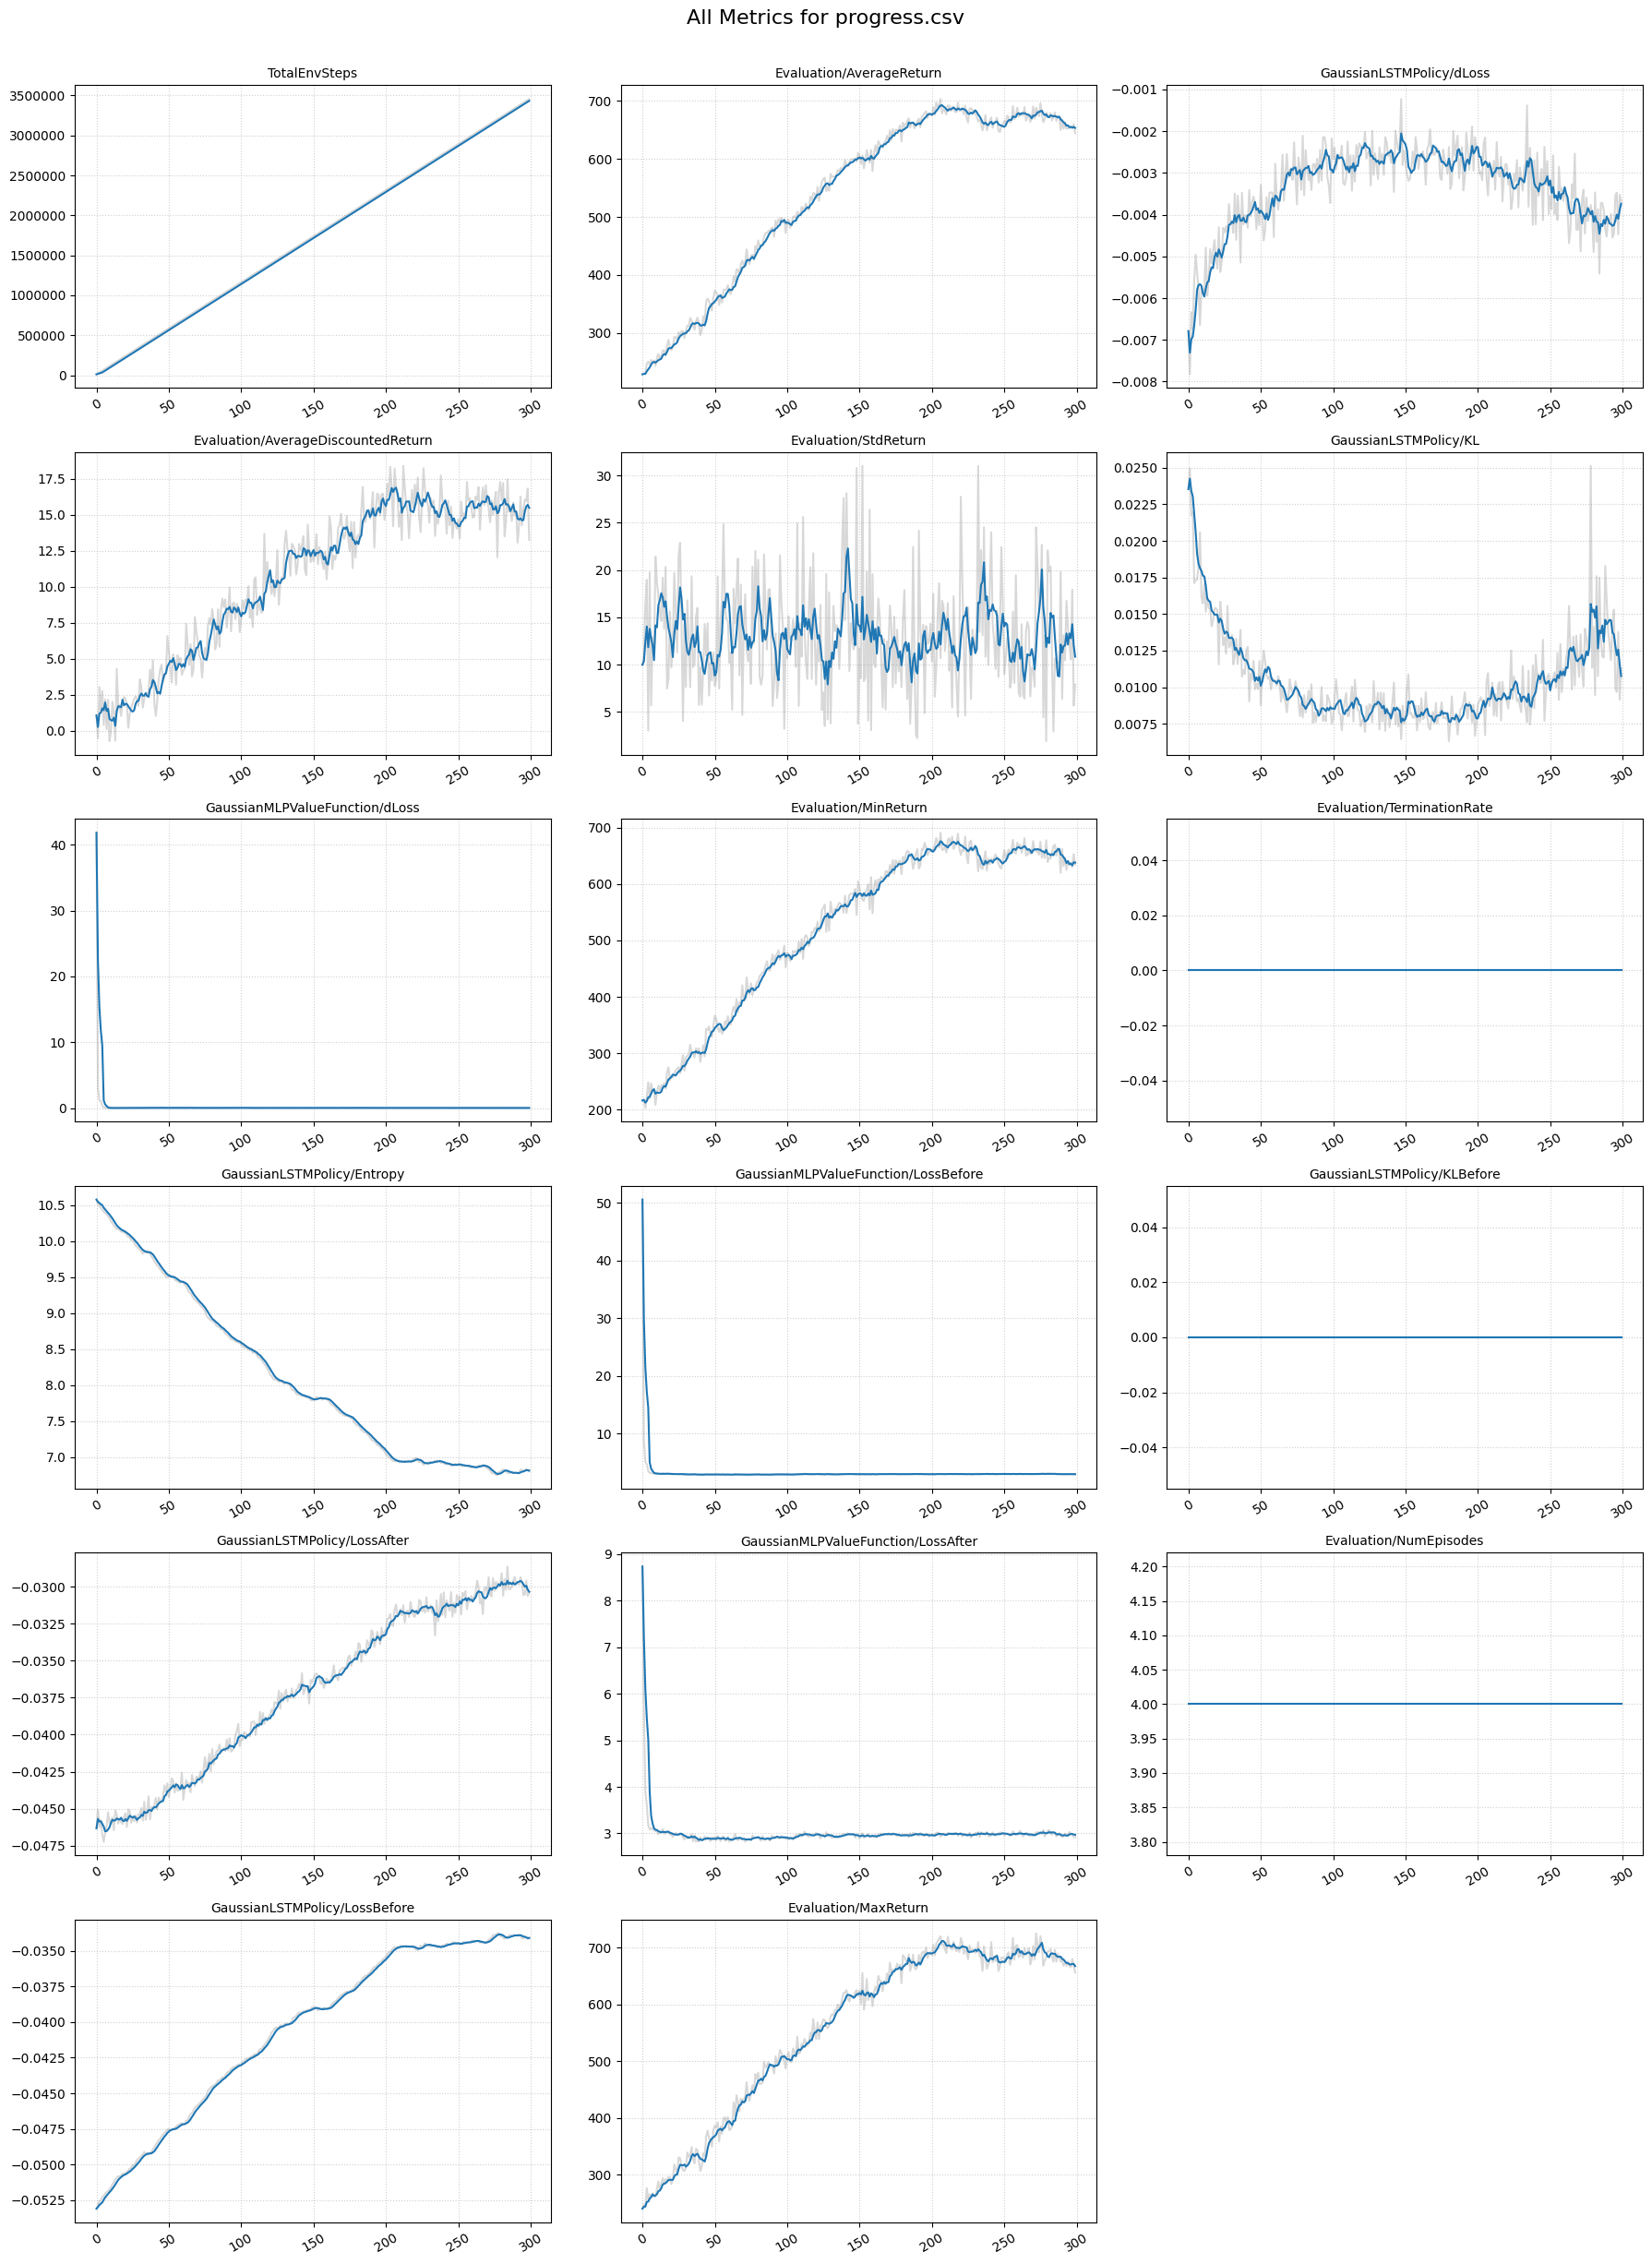

In [46]:
csv_path = '../data/local/garage/eplus_ppo_year_lstm_12/progress.csv'
plot_all_metrics(csv_path)

In [ ]:
plot_all_metrics("../data/local/garage/eplus_ppo_year_26/progress.csv")

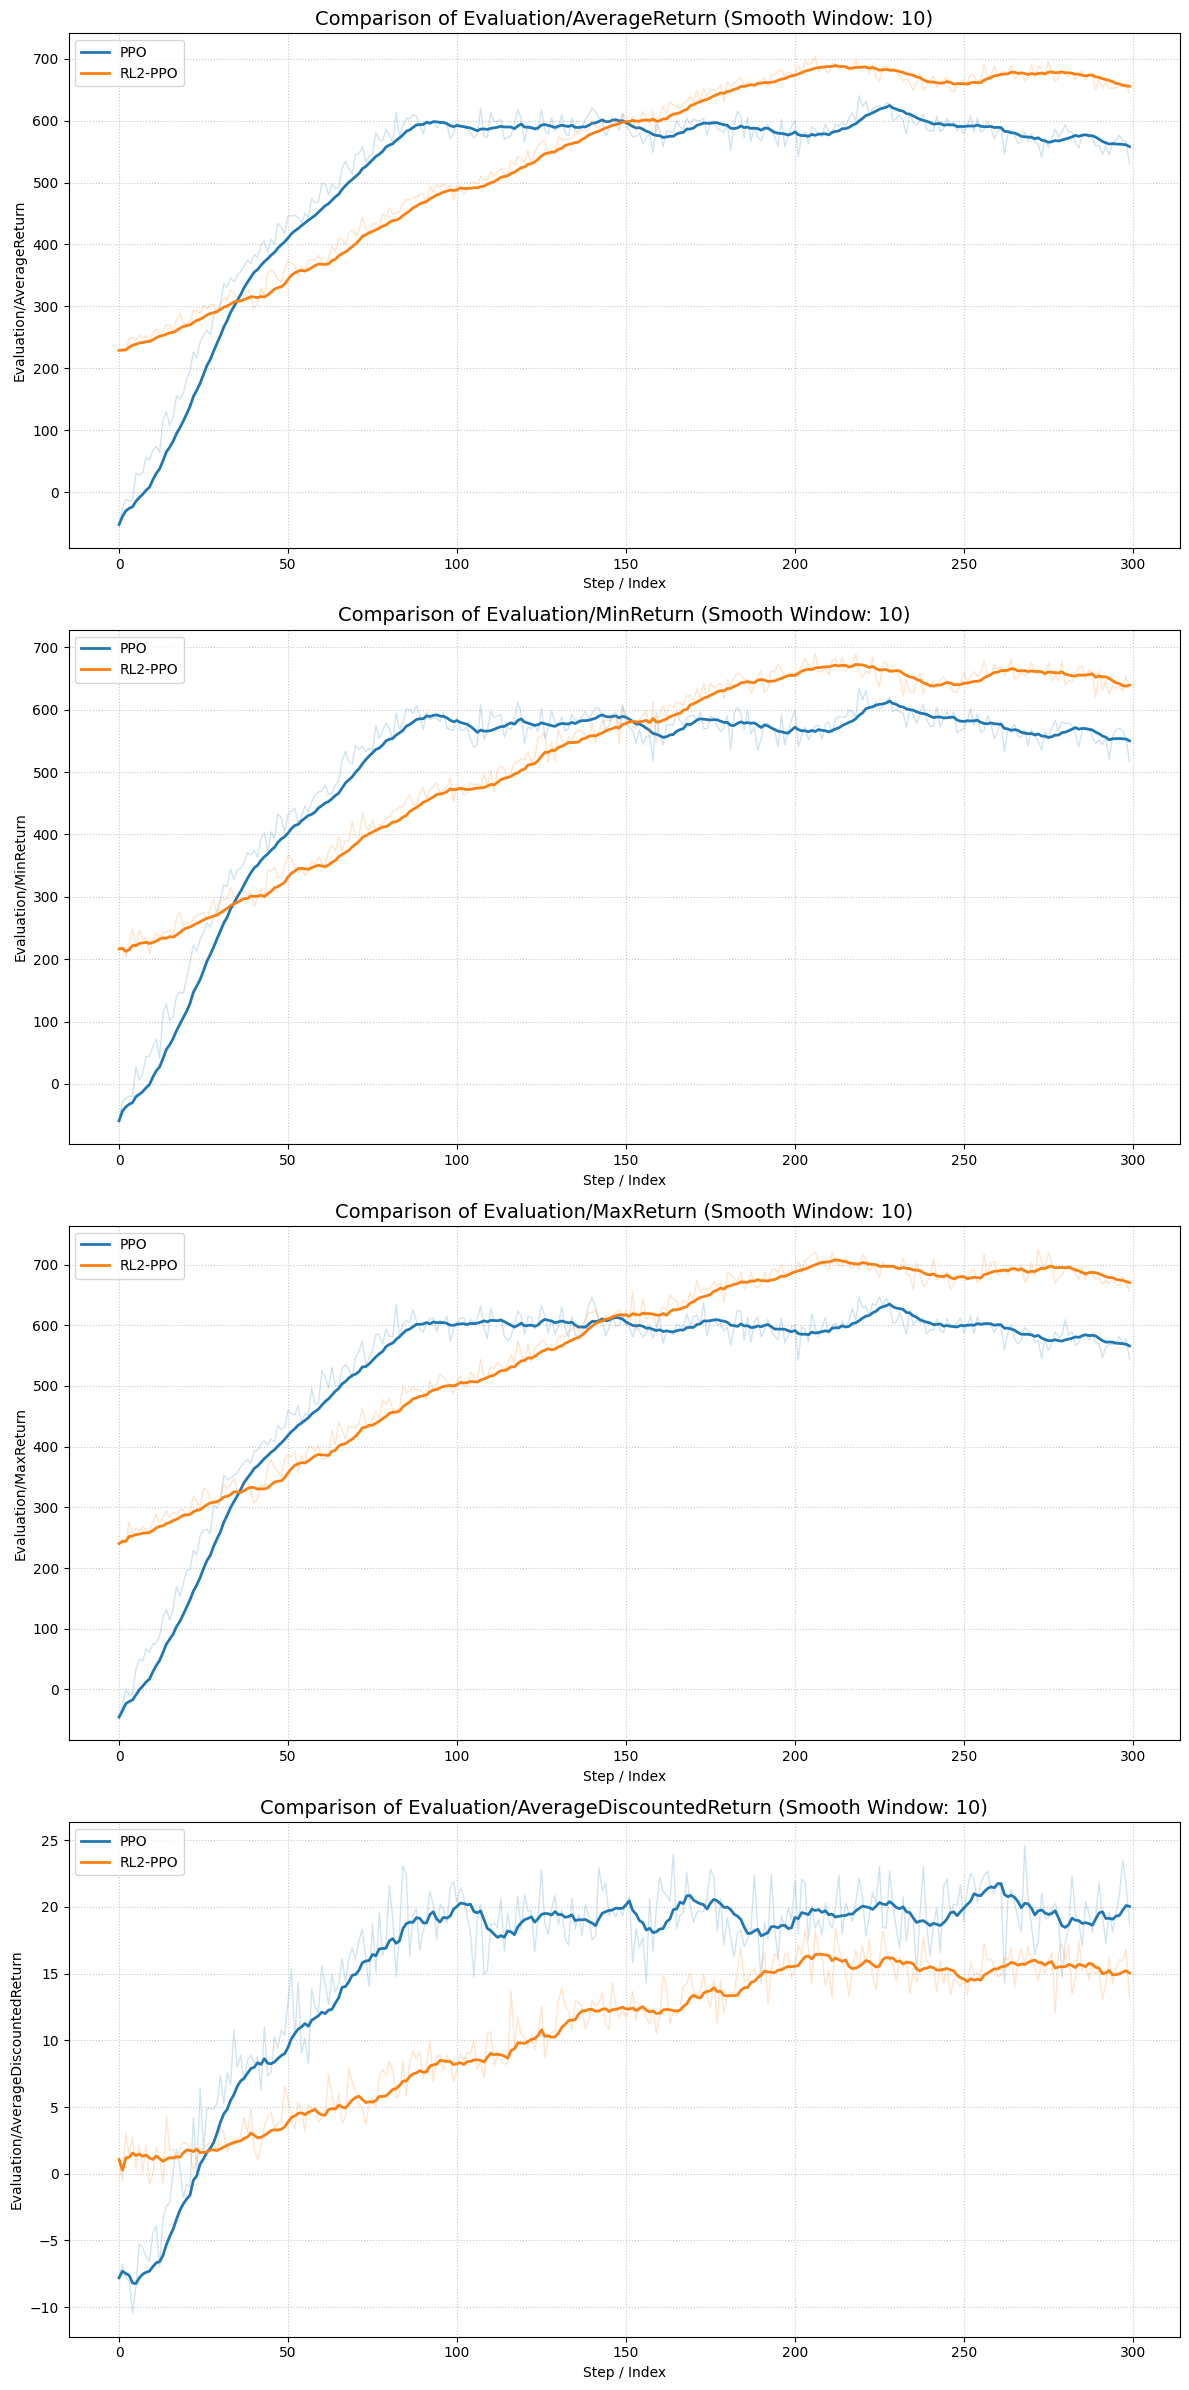

In [87]:
# 模拟路径
files = [
    "../data/local/garage/eplus_ppo_year_27/progress.csv",
    "../data/local/garage/eplus_ppo_year_lstm_12/progress.csv"
]

plot_csv_comparison(files, ["Evaluation/AverageReturn", 
                            # "GaussianMLPPolicy/Entropy",
                             "Evaluation/MinReturn", 
                             "Evaluation/MaxReturn", 
                            #  "GaussianMLPPolicy/KL", 
                             "Evaluation/AverageDiscountedReturn", 
                            #  "GaussianMLPPolicy/dLoss"
                             ],
                             ["PPO", "RL2-PPO"])
